In [ ]:
# 필요 라이브러리 불러오기 + 구글드라이브 연동

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 데이터 불러오고 구조살피기

data = pd.read_csv("drive/MyDrive/Colab Notebooks/Data/creditcard.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# 실 데이터 살펴보고 변수만들기

data.head(5)

x = data.drop(['Time','Class'],axis=1)
y = data['Class']

In [ ]:
# 데이터 분리

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# 만든 목적데이터들 정규화

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
# 모델 구성하기

model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # 이진분류 핵심
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 세팅

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 모델 적합

model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/3
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9991 - loss: 0.0073 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 2/3
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 3/3
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9994 - val_loss: 0.0028


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
===== Threshold 비교표 =====
   Threshold  Precision  Recall  F1-score
0        0.3     0.8523  0.7653    0.8065
1        0.4     0.8987  0.7245    0.8023
2        0.5     0.9701  0.6633    0.7879
3        0.6     0.9683  0.6224    0.7578
4        0.7     0.9818  0.5510    0.7059

ROC-AUC: 0.9772
PR-AUC: 0.826


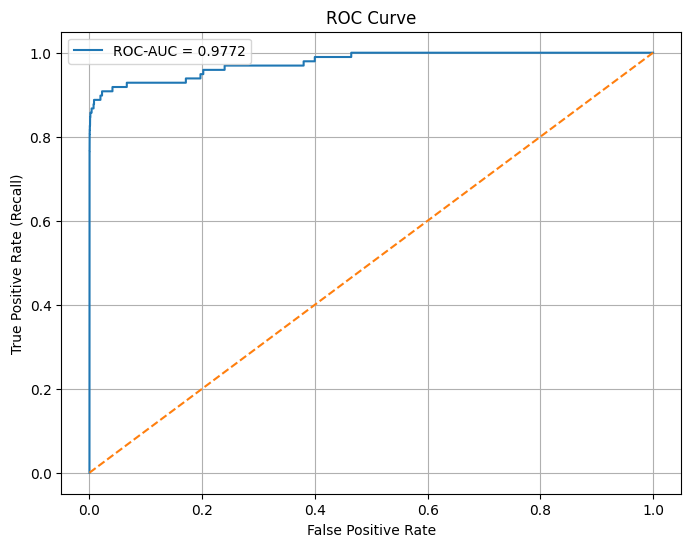

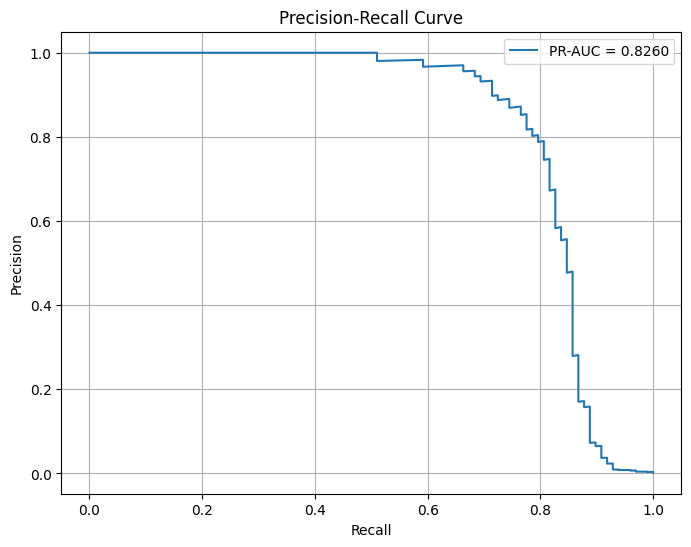

In [ ]:
# 모델 평가

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)


pred = model.predict(x_test)
pred = pred.flatten()

results = []
thresholds = [0.3,0.4,0.5,0.6,0.7]

# 이상치 기준 설정하기

for t in thresholds:

    pred_label = (pred > t).astype(int)

    precision = precision_score(y_test, pred_label)
    recall = recall_score(y_test, pred_label)
    f1 = f1_score(y_test, pred_label)

    results.append([
        t,
        np.round(precision,4),
        np.round(recall,4),
        np.round(f1,4)
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print("===== Threshold 비교표 =====")
print(results)

# -----------------------------------
# ROC-AUC 계산
# -----------------------------------

roc_auc = roc_auc_score(y_test, pred)
print("\nROC-AUC:", np.round(roc_auc,4))

# -----------------------------------
# PR-AUC 계산
# -----------------------------------

pr_auc = average_precision_score(y_test, pred)
print("PR-AUC:", np.round(pr_auc,4))

# -----------------------------------
# ROC Curve 함수 그리기
# -----------------------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, pred)
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.4f}'
)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

# -----------------------------------
# PR Curve 그리기
# -----------------------------------

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    pred
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f'PR-AUC = {pr_auc:.4f}'
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid()

plt.show()